# Urban Heat Islands & Climate Justice
### Sciences Po – Technology for Global Challenges, 2026

---

**Learning objectives**

By the end of this session you will be able to:
1. Load and visualise a long-run climate time series and quantify a warming trend.
2. Define *heatwaves* using a threshold-based rule and track their frequency and intensity over time.
3. Map *Local Climate Zones* (LCZ) as a proxy for urban heat exposure.
4. Combine socioeconomic and spatial data to analyse **climate justice** – who is most exposed to heat, and who has least access to care?

---

**Data used**

| Dataset | Source | Spatial scale |
|---------|--------|---------------|
| Daily temperature & precipitation (1970–2024) | Météo-France / SAFRAN | Point (Lyon) |
| Local Climate Zones 2022 | SPOT satellite | ~50 m polygons |
| Population & income grid | INSEE Filosofi 2019 | 200 m cells |
| Healthcare facilities | OpenStreetMap (Overpass) | Points |


https://mybinder.org/v2/gh/colinlenoble/TD1_sciencespo.git/HEAD?urlpath=%2Fdoc%2Ftree%2Fuhi_lesson_with_questions.ipynb

## 0 · Setup

In [233]:
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import geopandas as gpd
import seaborn as sns
from shapely.geometry import box
import warnings
import os
import rioxarray 
from cartopy.io import shapereader
warnings.filterwarnings('ignore')

# ── Shared style ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE = sns.color_palette("colorblind")
FIG_W, FIG_H = 11, 5


---
## Part 1 – Historical Climate Analysis




In [234]:
path = 'data/climate_lyon_daily.csv'
df_climate = pd.read_csv(path, parse_dates=['time'])
df_climate = df_climate[df_climate['time'].dt.year <= 2024]
df_climate.head()


,time,temperature,temperature_max,precipitation
0,1970-01-01,-2.1,-1.6,0.0
1,1970-01-02,-1.9,-0.4,0.0
2,1970-01-03,-3.6,-0.1,0.0
3,1970-01-04,2.3,10.0,3.7
4,1970-01-05,4.5,9.0,2.7


---
> **❓ Question 1 · Explore the dataset**
>
> - When does the dataset start? What is its temporal resolution?
> - Which variables are available?
> - How many observations does it contain?


We start with daily climate records for the Lyon grid cell from the SAFRAN reanalysis
(1970–2024).  The pre-processed CSV contains four variables:

| Column | Description | Unit |
|--------|-------------|------|
| `time` | Date | – |
| `temperature` | Mean daily temperature | °C |
| `temperature_max` | Maximum daily temperature | °C |
| `precipitation` | Daily precipitation | mm |

In [183]:
# -- YOUR CODE HERE --
# Explore the dataset: shape, dtypes, date range...
print(df_climate.shape)
print(df_climate.dtypes)
print(f"Period: {df_climate['time'].min().date()} -> {df_climate['time'].max().date()}")


(20089, 4)
time               datetime64[ns]
temperature               float64
temperature_max           float64
precipitation             float64
dtype: object
Period: 1970-01-01 -> 2024-12-31


### 1.1 Long-run temperature trend

We resample the daily series to **annual averages** and fit a linear trend to quantify warming.


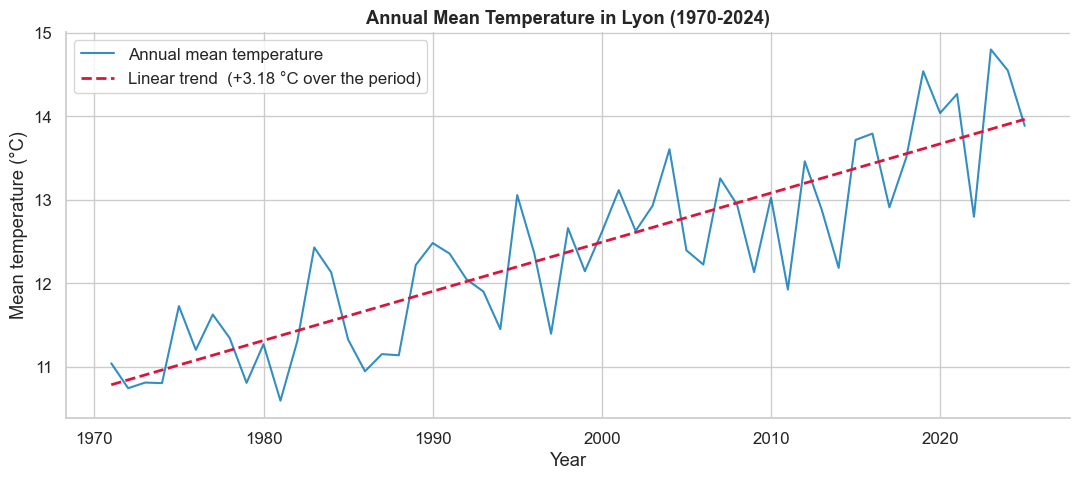

Estimated warming 1970->2024: 3.18 degrees C


In [218]:
# Annual mean temperature
df_annual = df_climate.set_index('time').resample('YE').mean().reset_index()

# Linear trend
X = np.arange(len(df_annual))
slope, intercept = np.polyfit(X, df_annual['temperature'].values, 1)
trend = intercept + slope * X
warming = trend[-1] - trend[0]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

ax.plot(df_annual['time'], df_annual['temperature'],
        color=PALETTE[0], linewidth=1.5, alpha=0.8, label='Annual mean temperature')
ax.plot(df_annual['time'], trend,
        color='crimson', linewidth=2, linestyle='--',
        label=f'Linear trend  (+{warming:.2f} °C over the period)')

ax.set_xlabel('Year')
ax.set_ylabel('Mean temperature (°C)')
ax.set_title('Annual Mean Temperature in Lyon (1970-2024)', fontweight='bold')
ax.legend(frameon=True)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
sns.despine()
plt.tight_layout()
plt.show()

print(f"Estimated warming 1970->2024: {warming:.2f} degrees C")


---
> **❓ Question 2 · Warming magnitude**
>
> - What is the estimated warming over 1970–2024?
> - Does this figure surprise you?
> - How does it compare to the global average (+1.1 °C since pre-industrial)? (see https://berkeleyearth.org/global-temperature-report-for-2025/)


### 1.2 Heatwaves

**Definition used here:**

A heatwave event start when when the daily mean temperature exceeds Spic.
It lasts until the daily mean temperature is above Sstart except if it drops below the threshold Sinterupt


In [ ]:
from utils import get_heatwaves

---
> **❓ Question 3 · Heatwave frequency over time**

> - Based on the helper function (see the file utils.py), explain the thresholds used to define a heatwave event and give their values
> - Plot the **number of heatwave events per year** as a bar chart with a linear trend line.
> - In which decade do the first events appear?
> - Is there a clear trend?


In [ ]:

heatwaves, thresholds = get_heatwaves(df_climate, temp_col='temperature')

print(
    f"Thresholds -> Spic (q99): {thresholds['Spic']:.2f}°C | "
    f"Sstart (q95): {thresholds['Sstart']:.2f}°C | "
    f"Sinterup (q90): {thresholds['Sinterup']:.2f}°C"
)
print(f"Total heatwave events detected: {len(heatwaves)}")
heatwaves.sort_values('duration_days', ascending=False).head(10)

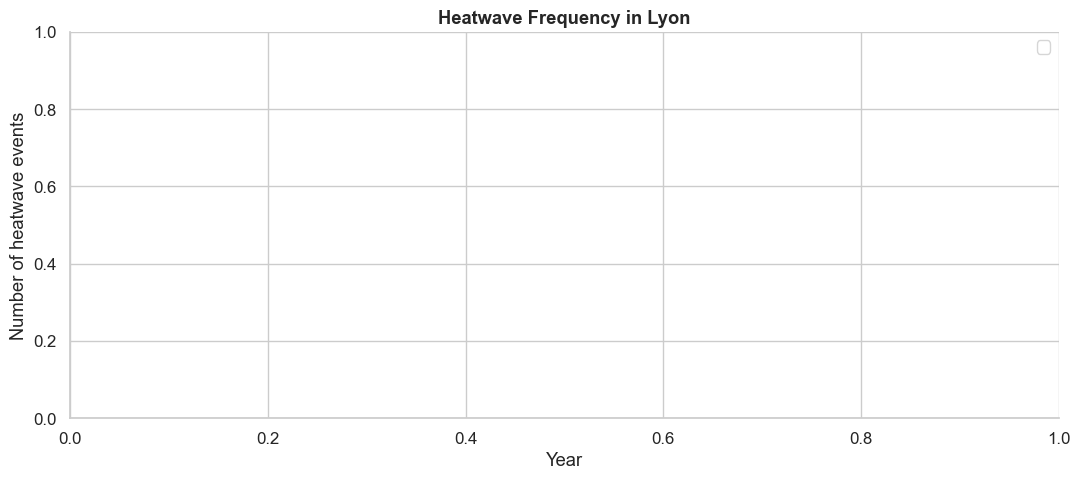

In [216]:
# -- FILL THE FOLLOWING CODE -- 

# Answer – heatwave frequency
all_years   = pd.Series(0, index=np.arange(1970, 2025))
hw_per_year = heatwaves.groupby('year').size()
hw_per_year = all_years.add(hw_per_year, fill_value=0)

X = np.arange(len(hw_per_year))
slope, intercept = np.polyfit(X, hw_per_year.values, 1)
trend_hw = intercept + slope * X

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
# ax.bar(TO FILL, TO FILL,
#        color=PALETTE[1], alpha=0.75, label='Heatwave events')
# ax.plot(TO FILL, TO FILL
#         color='crimson', linewidth=2, linestyle='--', label='Linear trend')
ax.set_xlabel('Year')
ax.set_ylabel('Number of heatwave events')
ax.set_title('Heatwave Frequency in Lyon',
             fontweight='bold')
ax.legend(frameon=True)
sns.despine()
plt.tight_layout()
plt.show()


---
> **❓ Question 4 · Longest heatwave**
>
> Which event had the longest duration? In which year did it occur?


In [220]:
# -- ENTER YOUR CODE HERE --

### 1.3 Heatwave days and intensity per year

Beyond frequency, two other metrics matter:
* **Heatwave days per year** – total days spent in heatwave conditions ($T > S_\text{start}$).
* **Annual intensity** – sum of per-event intensity indices as defined in 1.2, i.e. the cumulative normalised temperature excess $\sum \max(T - S_\text{start}, 0)\,/\,(S_\text{pic} - S_\text{start})$ aggregated over all events in the year. A higher value indicates years with more severe or prolonged heat stress.

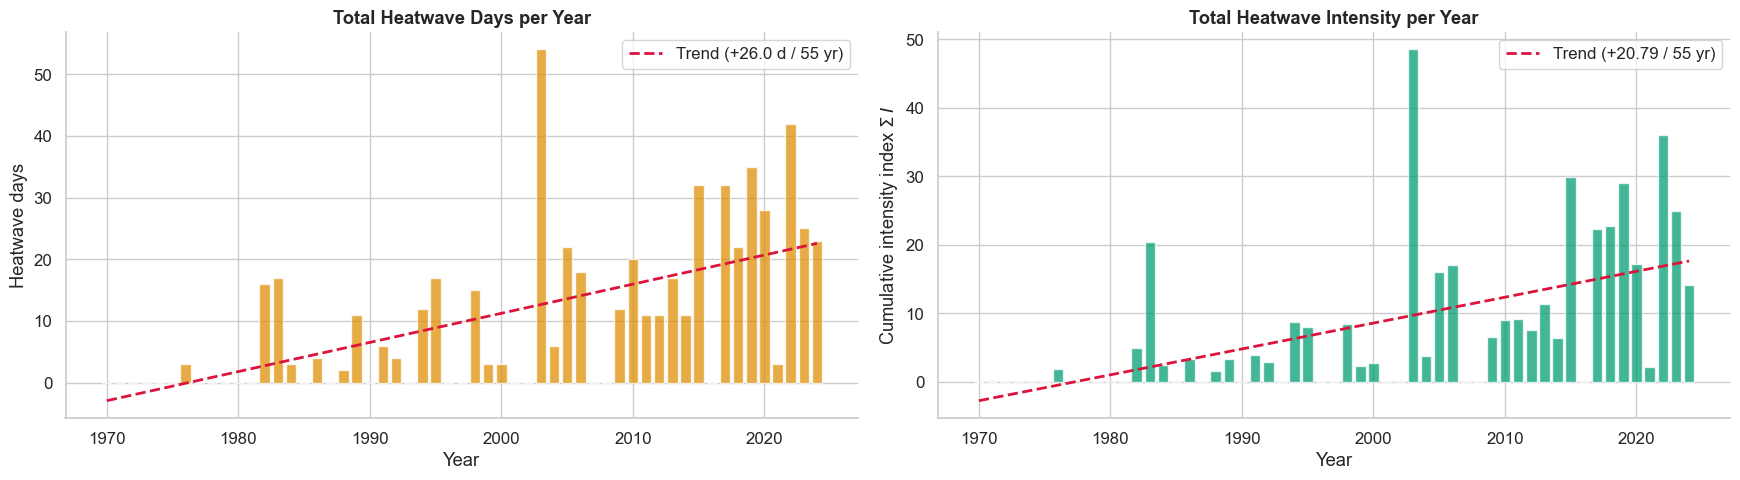

In [188]:
# ── Days per year ─────────────────────────────────────────────────────────────
all_years = pd.Series(0, index=df_annual['time'].dt.year.values, dtype=float)
days_per_year = heatwaves.groupby('year')['duration_days'].sum()
days_per_year = all_years.add(days_per_year, fill_value=0)

# ── Intensity per year: sum of per-event intensity indices (from 1.2) ─────────
intensity_per_year = heatwaves.groupby('year')['intensity'].sum()
intensity_per_year = intensity_per_year.reindex(all_years.index, fill_value=0)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(FIG_W * 1.6, FIG_H))

# Left: days
ax = axes[0]
Xd = np.arange(len(days_per_year))
sl, ic = np.polyfit(Xd, days_per_year.values, 1)
ax.bar(days_per_year.index, days_per_year.values,
       color=PALETTE[1], alpha=0.75)
ax.plot(days_per_year.index, ic + sl * Xd,
        color='crimson', linewidth=2, linestyle='--',
        label=f'Trend (+{sl*55:.1f} d / 55 yr)')
ax.set_xlabel('Year')
ax.set_ylabel('Heatwave days')
ax.set_title('Total Heatwave Days per Year', fontweight='bold')
ax.legend(frameon=True)

# Right: intensity
ax = axes[1]
Xi = np.arange(len(intensity_per_year))
sl2, ic2 = np.polyfit(Xi, intensity_per_year.values, 1)
ax.bar(intensity_per_year.index, intensity_per_year.values,
       color=PALETTE[2], alpha=0.75)
ax.plot(intensity_per_year.index, ic2 + sl2 * Xi,
        color='crimson', linewidth=2, linestyle='--',
        label=f'Trend (+{sl2*55:.2f} / 55 yr)')
ax.set_xlabel('Year')
ax.set_ylabel(r'Cumulative intensity index $\Sigma\,I$')
ax.set_title('Total Heatwave Intensity per Year', fontweight='bold')
ax.legend(frameon=True)

sns.despine()
plt.tight_layout()
plt.show()

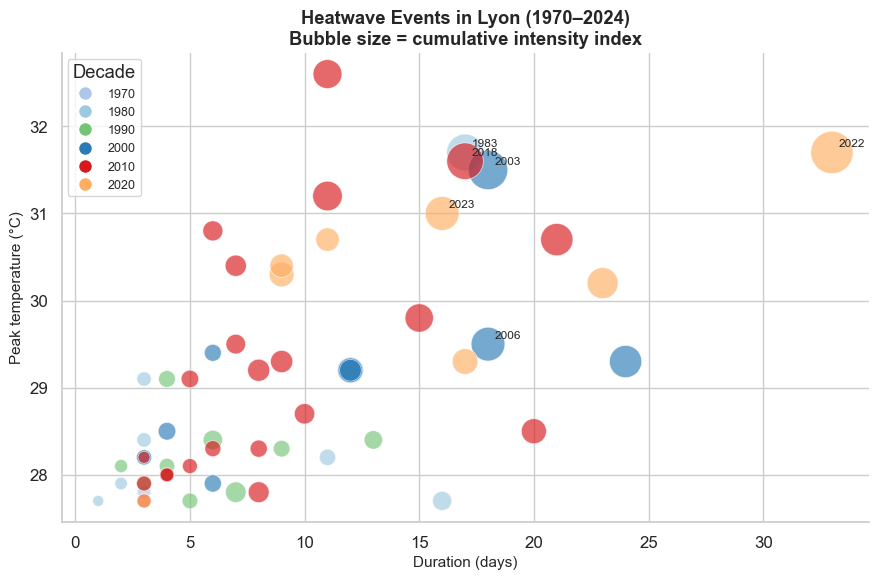

In [189]:
# ── Bubble chart: duration (x), max_temp (y), bubble size = intensity ─────────
from matplotlib.lines import Line2D

# Scale bubble area proportional to intensity
sz = (heatwaves['intensity'] / heatwaves['intensity'].max()) * 900 + 30

# Colour by decade
decade = (heatwaves['year'] // 10) * 10
decade_colors = {1970: '#aec7e8', 1980: '#9ecae1', 1990: '#74c476',
                 2000: '#2c7bb6', 2010: '#d7191c', 2020: '#fdae61'}
colors = decade.map(decade_colors)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(heatwaves['duration_days'], heatwaves['max_temp'],
           s=sz, c=colors, alpha=0.65, edgecolors='white', linewidths=0.6)

# Label the 6 most intense events
for _, row in heatwaves.nlargest(6, 'intensity').iterrows():
    ax.annotate(str(int(row['year'])),
                xy=(row['duration_days'], row['max_temp']),
                xytext=(5, 4), textcoords='offset points', fontsize=8.5)

ax.set_xlabel('Duration (days)', fontsize=11)
ax.set_ylabel('Peak temperature (°C)', fontsize=11)
ax.set_title('Heatwave Events in Lyon (1970–2024)\nBubble size = cumulative intensity index',
             fontweight='bold')

# Decade legend
handles = [Line2D([0], [0], marker='o', color='w',
                  markerfacecolor=c, markersize=10, label=str(d))
           for d, c in decade_colors.items() if d in decade.values]
ax.legend(handles=handles, title='Decade', frameon=True, loc='upper left', fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

---
> **❓ Question 5 · Analysis of the dependence between duration, peak and intensity**
>
> What are your thoughts on the links between duration, peak and intensity ? Where does that come from?

---
## Part 2 – Spatial Exposure: Local Climate Zones

**Local Climate Zones (LCZ)** classify urban and rural landscapes into 17 types based on
surface cover, building morphology, and human activity.  In the context of urban heat:

| LCZ class | Description | 
|-----------|-------------|
| 1 | Compact high |
| 2 | Compact mid-rise |
| 3 | Compact low-rise |
| 4 | Open high-rise |
| 5 | Open mid-rise |
| 6 | Open low-rise |
| 7 | Lightweight low-rise, densely built |
| 8 | Large buildings |
| 9 |  Scattered settlement of houses |
| A - 11 | Densely wooded areas |
| B - 12 | Sparse wooded area |
| C - 13 | Heterogeneous green space |
| D - 14 | Low vegetation |
| E - 15 | Bare rock or paved |
| F - 16 | Bare soil or sand |
| G - 17 | Water | 

We load a pre-processed GeoPackage that combines LCZ polygons with:
- `ind` – total population (200 m grid)
- `ind_80p` – population aged 80+
- `ind_snv` – median standard of living (euros/year)
- `ver` – vegetation cover (%)
- `ror` – impervious surface cover (%)
- `dist_hospital` – distance to nearest hospital/clinic (m)


In [235]:
path = 'data/ds_filo_lcz_aligned.nc'
ds = xr.open_dataset(path)

# Assign source CRS, then reproject
ds = ds.rio.write_crs("EPSG:2154", inplace=False)
ds = ds.rio.reproject("EPSG:4326")

# We choose to clip the dataset to the central half of the grid to focus on the core urban area
lenx = ds.dims["x"]
leny = ds.dims["y"]
ds_clip = ds.isel(x=slice(lenx//4, 3*lenx//4), y=slice(leny//4, 3*leny//4))


> **❓ Question 6 · Explore the dataset

> - What are the dimensions of the dataset ?
> - What are the resolution ?
> - Check the variable names and their meaning. Which ones are relevant for our analysis of heat exposure and climate justice?


<!-- ...existing code... -->
### 2.1 Spatial Exploration (Lyon + périphérie proche)

Here's a  **helper** function (`make_explorer_dualmap`) to quickly plot two comparable maps (same basemap, same extents, independent colorbars).
I give you an example of how to use it below, but feel free to explore any pairing of variables you like.



Bounds [[45.57293929658364, 4.662844252689661], [45.93917392390228, 5.156670298558022]] | centre [45.756056610242965, 4.909757275623841] | flip_y False



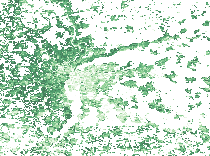
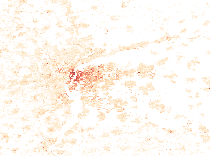

In [238]:
import folium
from folium.plugins import DualMap
from utils import _to_png_url, _mask_to_png, _arr_to_png, make_explorer_dualmap

# ── Shared map parameters (ds_clip is in EPSG:4326) ──────────────────────────
_BOUNDS = [[float(ds_clip.y.min()), float(ds_clip.x.min())],
           [float(ds_clip.y.max()), float(ds_clip.x.max())]]
_CENTER = [(_BOUNDS[0][0] + _BOUNDS[1][0]) / 2,
           (_BOUNDS[0][1] + _BOUNDS[1][1]) / 2]
_FLIP_Y = bool(ds_clip.y.values[0] < ds_clip.y.values[-1])
print(f"Bounds {_BOUNDS} | centre {_CENTER} | flip_y {_FLIP_Y}")

left_specs = [(ds_clip.ver, 'Greens', 'Vegetation %')]
right_specs = [(ds_clip.bur, 'OrRd', 'Built-up ratio %')]

make_explorer_dualmap(left_specs, right_specs, bounds=_BOUNDS, center=_CENTER,
                      flip_y=_FLIP_Y, zoom_start=12, basemap="CartoDB positron")

Compare any pairing of variables using the **DualMap** above. 
Make comparisons between the groups of variables below:

| Group | Layers |
|-------|--------|
| **LCZ zones** | Compact (1–3) · Open/mixed (4–10) · Natural (11–15) |
| **LCZ indicators** | Built-up · Vegetation · Impervious · Bare-soil · Veg. height |
| **Socio-economic** | Population · Median income · Elderly share · Children share · Poverty rate |

> **❓ Question 6 · Spatial distribution of LCZ classes**
>
> 1. Where are the compact urban classes (1–3) concentrated?
> 2. Where are the natural classes (11–15) mostly found?
> 3. Now switch the right panel to **"LCZ zones: Open / Mixed (4–10)"**.
>    Is there a clear spatial gradient from the city centre to the periphery?

> **❓ Question 7 · LCZ physical indicators**
>
> The indicators used to build the LCZ classification are documented at:
> <https://www.data.gouv.fr/api/1/datasets/r/f80e08a4-ecd1-42a2-a8d6-963af16aec75>
>
> 1. Which indicator is highest in the city centre?
> 2. BUR and ROR both measure "artificial" surfaces. What are their differences ? how do they differ spatially?
> 3. Where does VER peak? Does it overlap with the compact LCZ classes from Q6?

> **❓ Question 8 · Socio-economic indicators**
>
> 1. Where is population most concentrated in the Lyon area?
> 2. Do the highest-income areas overlap with the most densely populated zones?
> 3. Which age groups appear to be spatially segregated?
> 4. Visualize the minimal distance to healthcare facilities? Where are the healthcare deserts?

> **❓ Question 9 · Vegetation cover and income**
>
> 1. Is there a visible spatial correlation between vegetation cover and income?
>    *(Do green areas and high-income areas tend to coincide?)*
> 2. Which areas combine **high built-up / impervious surface** AND **low income**?
>    Why might this double burden be a climate justice concern?
> 3. Formulate a one-sentence hypothesis linking LCZ class, vegetation, and income.
> 4. Do you see any patterns between age groups and vegetation cover or income ? 
> 5. Are there any spatial correlation between distance to healthcare facilities and income or vegetation cover ? What are the regions of high concern in terms of climate justice ?

> **❓ Question 10 · Quantitative comparison across LCZ groups**
>
> Calculate the mean vegetation cover, built-up cover, median income, share of elderly population (80+), share of children (0–5), and average distance to healthcare facilities for each of the three LCZ groups (compact urban 1–3, open/mixed urban 4–10, natural 11–15).
>
> 1. Does that confirm your visual impressions from the maps?
> 2. How would you summarise the differences between the three LCZ groups in terms of heat exposure and socio-economic vulnerability?

In [243]:
# ANSWER
# 
#  Compare indicators across 3 LCZ groups: 1–3, 4–10, 11–15
lcz_groups = {
    "LCZ 1–3 (compact urban)": [1, 2, 3],
    "LCZ 4–10 (open/mixed urban)": [4, 5, 6, 7, 8, 9, 10],
    "LCZ 11–15 (natural)": [11, 12, 13, 14, 15],
}

rows = []
for group_name, classes in lcz_groups.items():
    mask = ds_clip["lcz_int"].isin(classes)

    total_pop = ds_clip["ind"].where(mask).sum(dim=["x", "y"], skipna=True).item()
    old_pop = ds_clip["ind_80p"].where(mask).sum(dim=["x", "y"], skipna=True).item()
    young_pop = ds_clip["ind_0_5"].where(mask).sum(dim=["x", "y"], skipna=True).item()

    rows.append({
        "LCZ group": group_name,
        "Mean vegetation cover (%)": ds_clip["ver"].where(mask).mean(dim=["x", "y"], skipna=True).item(),
        "Built-up ratio (%)": ds_clip["bur"].where(mask).mean(dim=["x", "y"], skipna=True).item(),
        "Mean median standard of living (€/year)": ds_clip["ind_snv"].where(mask).mean(dim=["x", "y"], skipna=True).item(),
        "Total population": int(round(total_pop)),
        "Share population aged 80+ (%)": round(old_pop / total_pop * 100, 2) if total_pop > 0 else 0,
        "Share population aged 0–5 (%)": round(young_pop / total_pop * 100, 2) if total_pop > 0 else 0,
        "Number of cells": int(mask.sum().item())
    })

table_lcz_compare = pd.DataFrame(rows)

display(
    table_lcz_compare.style
    .format({
        "Mean vegetation cover (%)": "{:,.2f}",
        "Built-up ratio (%)": "{:,.2f}",
        "Mean median standard of living (€/year)": "{:,.2f}",
        "Total population": "{:,}",
        "Share population aged 80+ (%)": "{:,.2f}",
        "Share population aged 0–5 (%)": "{:,.2f}",
        "Number of cells": "{:,}"
    })
    .hide(axis="index")
    .set_caption("Comparison of vegetation, income, and population structure across LCZ groups")
)

LCZ group,Mean vegetation cover (%),Built-up ratio (%),Mean median standard of living (€/year),Total population,Share population aged 80+ (%),Share population aged 0–5 (%),Number of cells
LCZ 1–3 (compact urban),10.21,54.62,"26,400.29","173,939",4.33,7.11,235
LCZ 4–10 (open/mixed urban),52.75,18.58,"28,366.60","799,204",4.95,8.04,"5,435"
LCZ 11–15 (natural),76.72,1.98,"30,046.93","355,062",5.20,7.70,"6,978"


---
## Part 3 – Climate Justice Analysis

We now test whether socioeconomic status predicts exposure to heat risk factors.
We divide the study area into **income deciles** (D1 = poorest 10%, D10 = richest 10%)
and compare four indicators across deciles.


In [195]:
# Convert the xarray dataset to a tabular dataframe
lcz = ds_clip.to_dataframe().reset_index()

# Work only on cells with population/income data and urban LCZ (class < 10)
dt = lcz.dropna(subset=['lcz_int', 'ind_snv', 'ver', 'ror', 'dist_hospital', 
                        'dist_clinic', 'dist_doctors']).copy()
dt = dt[dt['lcz_int'] < 10].copy()   # exclude natural / rural zones

# Income deciles
dt['decile_snv'] = pd.qcut(dt['ind_snv'].rank(method='first'), 10, labels=False)

print(f"Urban polygons with income data: {len(dt):,}")



Urban polygons with income data: 5,670


### 3.1 Vegetation cover by income decile

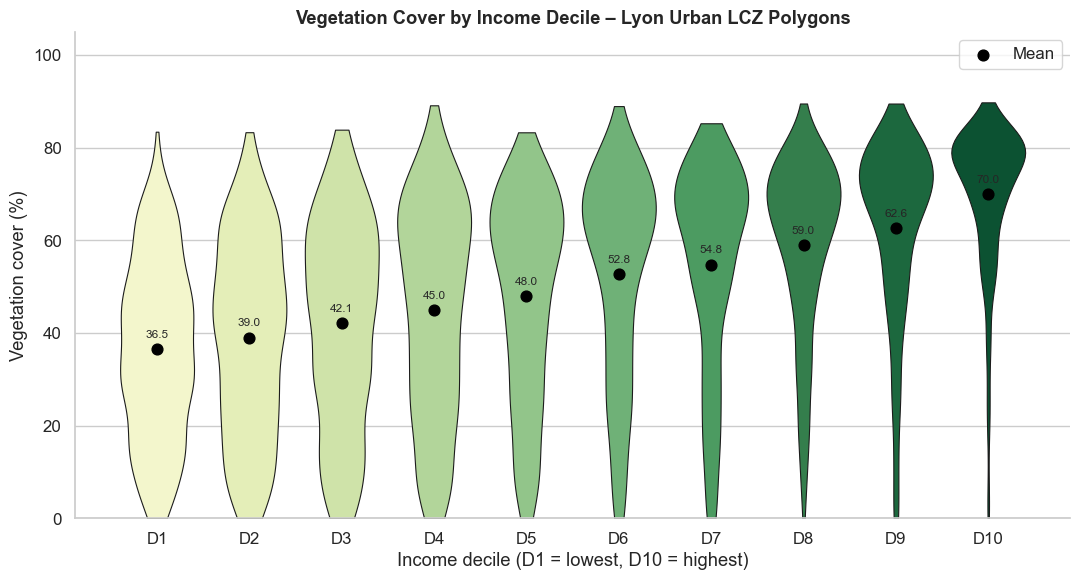

In [196]:
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H + 1))

pal_g = sns.color_palette("YlGn", 10)
sns.violinplot(x='decile_snv', y='ver', data=dt,
               order=range(10), palette=pal_g, ax=ax,
               inner=None, cut=0, linewidth=0.8)

means_ver = dt.groupby('decile_snv')['ver'].mean()
ax.scatter(means_ver.index, means_ver.values,
           color='black', s=60, zorder=5, label='Mean')

for i, val in enumerate(means_ver):
    ax.text(i, val + 2.5, f'{val:.1f}', ha='center', fontsize=8.5)

ax.set_xticks(range(10))
ax.set_xticklabels([f'D{i+1}' for i in range(10)])
ax.set_xlabel('Income decile (D1 = lowest, D10 = highest)')
ax.set_ylabel('Vegetation cover (%)')
ax.set_title('Vegetation Cover by Income Decile – Lyon Urban LCZ Polygons',
             fontweight='bold')
ax.set_ylim(0, 105)
ax.legend(frameon=True)
sns.despine()
plt.tight_layout()
plt.show()


---
> **❓ Question 6 · Green inequality**
>
> - Describe the relationship between income and vegetation cover.
> - Is the difference between D1 and D10 large?
> - What policy interventions could reduce this gap?


### 3.2 Impervious surface cover by income decile

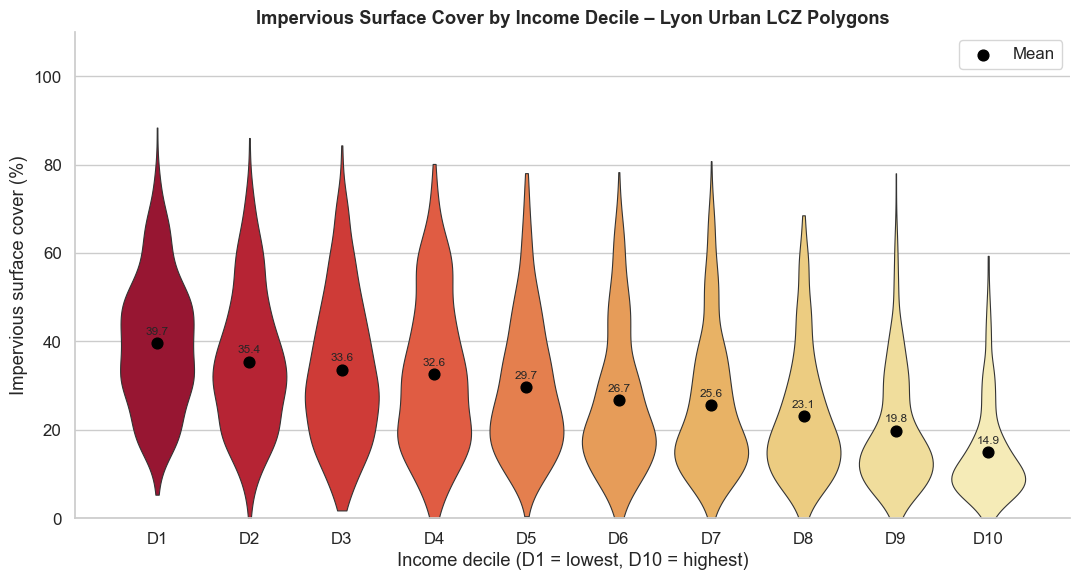

In [197]:
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H + 1))

pal_r = sns.color_palette("YlOrRd", 10)[::-1]
sns.violinplot(x='decile_snv', y='ror', data=dt,
               order=range(10), palette=pal_r, ax=ax,
               inner=None, cut=0, linewidth=0.8)

means_ror = dt.groupby('decile_snv')['ror'].mean()
ax.scatter(means_ror.index, means_ror.values,
           color='black', s=60, zorder=5, label='Mean')

for i, val in enumerate(means_ror):
    ax.text(i, val + 2, f'{val:.1f}', ha='center', fontsize=8.5)

ax.set_xticks(range(10))
ax.set_xticklabels([f'D{i+1}' for i in range(10)])
ax.set_xlabel('Income decile (D1 = lowest, D10 = highest)')
ax.set_ylabel('Impervious surface cover (%)')
ax.set_title('Impervious Surface Cover by Income Decile – Lyon Urban LCZ Polygons',
             fontweight='bold')
ax.set_ylim(0, 110)
ax.legend(frameon=True)
sns.despine()
plt.tight_layout()
plt.show()


### 3.3 Distance to nearest hospital/clinic by income decile

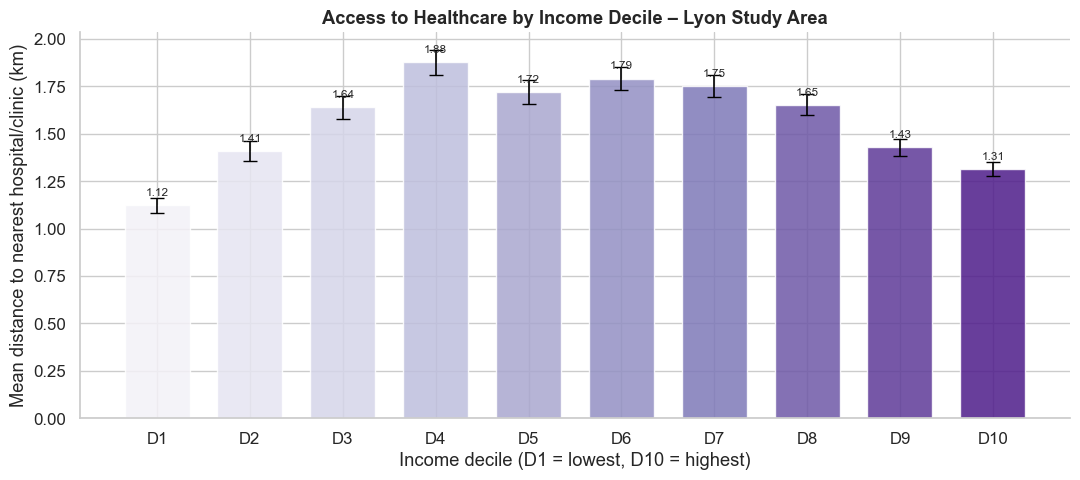

In [198]:
stats_h = dt.groupby('decile_snv')['dist_doctors'].agg(['mean','sem']).sort_index()
stats_h.columns = ['mean', 'sem']

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
pal_p = sns.color_palette("Purples", 10)
ax.bar(stats_h.index, stats_h['mean'] / 1000,
       color=pal_p, alpha=0.85, width=0.7)
ax.errorbar(stats_h.index, stats_h['mean'] / 1000,
            yerr=stats_h['sem'] / 1000,
            fmt='none', ecolor='black', capsize=5, linewidth=1.2)

for i, val in enumerate(stats_h['mean'] / 1000):
    ax.text(i, val + 0.05, f'{val:.2f}', ha='center', fontsize=8.5)

ax.set_xticks(range(10))
ax.set_xticklabels([f'D{i+1}' for i in range(10)])
ax.set_xlabel('Income decile (D1 = lowest, D10 = highest)')
ax.set_ylabel('Mean distance to nearest hospital/clinic (km)')
ax.set_title('Access to Healthcare by Income Decile – Lyon Study Area',
             fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()


---
> **❓ Question 11 · Decomposition in deciles**
>
> Combining the findings from sections 3.1, 3.2, and 3.3:
>
> 1. Compare the results with the visual impressions and spatial patterns you observed in Part 2.
> 2. Is there any income group that faces a particularly high burden of heat exposure and low access to healthcare?


---
### 3.4 Synthesis: linear regression with confidence intervals

We now formalise the relationships observed visually in the bivariate maps
by fitting OLS regressions at the **pixel level**.
Two outcome variables capture complementary dimensions of climate vulnerability:

| Dependent variable | Interpretation |
|--------------------|----------------|
| Vegetation cover `ver` (%) | Direct heat-mitigation capacity of each cell |
| Share of elderly 80+ (`ind_80p / ind`) | Age-related vulnerability to extreme heat |

For each, the explanatory variable is **median standard of living** (`ind_snv`, k€/year).
The shaded band shows the **95 % pointwise confidence interval** of the regression line.

VIF values for predictors:
  Income: 1.12
  Elderly Share: 1.00
  Population Density: 1.12


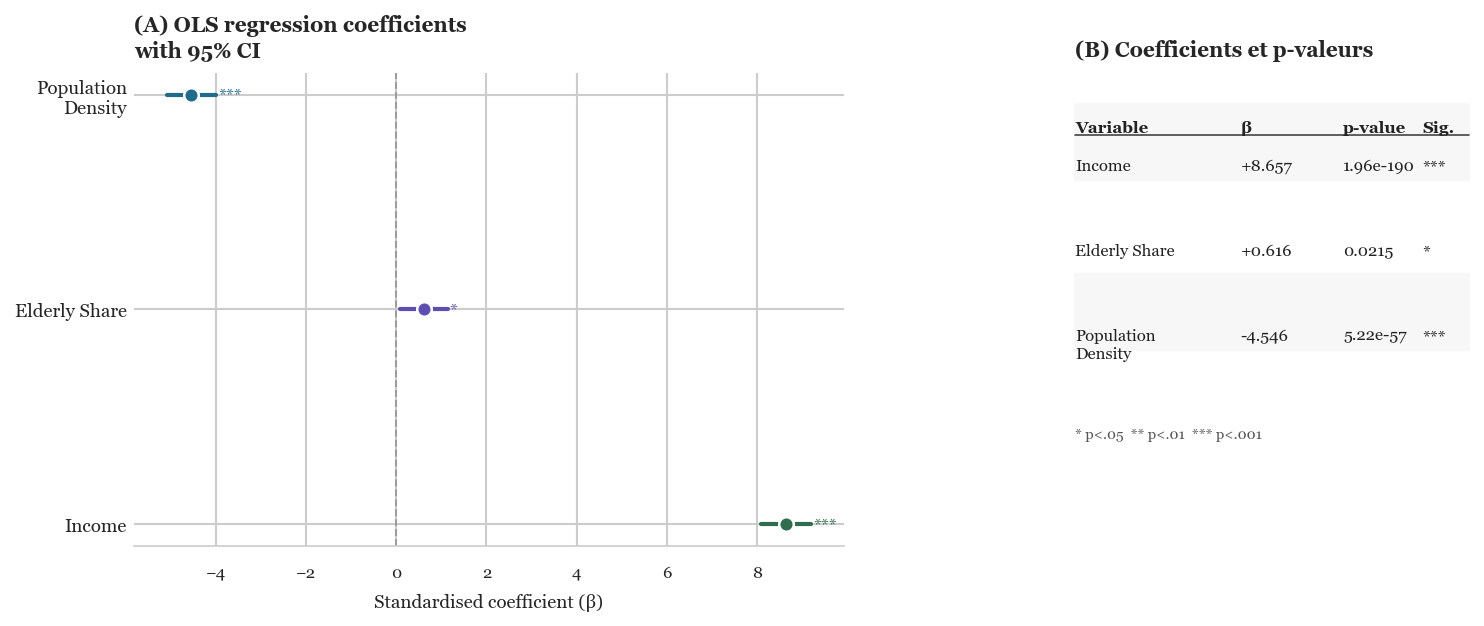

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
import matplotlib as mpl


snv_flat = dt['ind_snv'].values
elderly_rate = dt['ind_80p'].values / dt['ind'].values * 100
ind_flat = dt['ind'].values
ver_flat = dt['ver'].values


# ── Scaling ───────────────────────────────────────────────────────────────────
scaler = StandardScaler()
snv_scaled     = scaler.fit_transform(snv_flat.reshape(-1, 1)).flatten()
elderly_scaled = scaler.fit_transform(elderly_rate.reshape(-1, 1)).flatten()
ind_scaled     = scaler.fit_transform(ind_flat.reshape(-1, 1)).flatten()

mask = np.isfinite(ver_flat) & np.isfinite(snv_flat) & np.isfinite(elderly_rate)

X_raw = np.column_stack([snv_scaled[mask], elderly_scaled[mask], ind_scaled[mask]])
X     = sm.add_constant(X_raw)
y     = ver_flat[mask]

model = sm.OLS(y, X).fit()

# ── Correlation matrix ────────────────────────────────────────────────────────
pred_df = pd.DataFrame(X_raw, columns=["Income", "Elderly\nShare", "Pop.\nDensity"])
corr    = pred_df.corr()

# ── Regression results ────────────────────────────────────────────────────────
coefs  = model.params[1:]
pvals  = model.pvalues[1:]
# Make outputs indexable with .iloc even when statsmodels returns ndarrays
conf_raw = model.conf_int()
if isinstance(conf_raw, np.ndarray):
    conf = pd.DataFrame(conf_raw, columns=["low", "high"]).iloc[1:].reset_index(drop=True)
else:
    conf = conf_raw.iloc[1:].copy()
    conf.columns = ["low", "high"]
    conf = conf.reset_index(drop=True)

pvals = pd.Series(model.pvalues).iloc[1:].reset_index(drop=True)
labels = ["Income", "Elderly Share", "Population\nDensity"]
colors = ['#2E6D4E', '#5E4DB2', '#1E6B8C']

def sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "n.s."

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE LAYOUT  — 3 panels: (A) coef plot | (B) corr matrix | (C) stats table
# ═══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(10, 4.5))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.42,
                        left=0.08, right=0.97, top=0.88, bottom=0.18,
                        width_ratios=[1.8, 1])

ax_coef  = fig.add_subplot(gs[0])
ax_table = fig.add_subplot(gs[1])

# ── Panel A: Coefficient plot ─────────────────────────────────────────────────
for idx, (label, coef, color) in enumerate(zip(labels, coefs, colors)):
    lo, hi = conf["low"].iloc[idx], conf["high"].iloc[idx]
    ax_coef.plot([lo, hi], [idx, idx], color=color, lw=2, solid_capstyle='round', zorder=2)
    ax_coef.plot(coef, idx, 'o', color=color, markersize=7, zorder=3,
                 markeredgecolor='white', markeredgewidth=1.2)
    stars = sig_stars(pvals.iloc[idx])
    ax_coef.text(hi + 0.02, idx, stars, va='center', ha='left',
                 fontsize=8, color=color, fontstyle='italic')

ax_coef.axvline(0, color='#999999', linestyle='--', linewidth=0.9, zorder=1)
ax_coef.set_yticks(range(len(labels)))
ax_coef.set_yticklabels(labels, fontsize=9)
ax_coef.set_xlabel("Standardised coefficient (β)", labelpad=6)
ax_coef.set_title("(A) OLS regression coefficients\nwith 95% CI", loc='left',
                   fontweight='bold', pad=8)

ax_coef.tick_params(axis='y', length=0)
ax_coef.spines['left'].set_visible(False)



for i in range(3):
    for j in range(3):
        # Matrice de corrélation retirée
        pass


    # ── Panneau droit: tableau des p-valeurs ──────────────────────────────────────
    ax_table.clear()
    ax_table.axis('off')
    ax_table.set_title("(B) Coefficients et p-valeurs", loc='left', fontweight='bold', pad=8)

    col_headers = ["Variable", "β", "p-value", "Sig."]
    rows = []
    for lab, coef, p in zip(labels, coefs, pvals):
        rows.append([lab, f"{coef:+.3f}", f"{p:.3g}", sig_stars(p)])

    # Positions en coordonnées d'axes
    col_x = [0.00, 0.42, 0.68, 0.88]
    header_y = 0.90
    row_h = 0.18

    # Header
    for cx, ch in zip(col_x, col_headers):
        ax_table.text(cx, header_y, ch, fontsize=8, fontweight='bold',
              va='top', ha='left', color='#222222', transform=ax_table.transAxes)

    # Ligne sous header (sans axhline+transform)
    ax_table.plot([0, 1], [header_y - 0.03, header_y - 0.03],
              color='#444444', lw=0.8, transform=ax_table.transAxes, clip_on=False)

    # Rows
    for r_idx, row in enumerate(rows):
        y_pos = header_y - 0.08 - r_idx * row_h
        bg_color = '#F7F7F7' if r_idx % 2 == 0 else 'white'
        ax_table.add_patch(plt.Rectangle((0, y_pos - 0.045), 1.0, row_h - 0.02,
                         color=bg_color, transform=ax_table.transAxes,
                         clip_on=False, zorder=0))
        for cx, cell in zip(col_x, row):
            ax_table.text(cx, y_pos, cell, fontsize=8, va='top', ha='left',
                  color='#222222', transform=ax_table.transAxes)

    # Footer court
    footer_y = header_y - 0.08 - len(rows) * row_h - 0.03
    ax_table.text(0, footer_y,
              "* p<.05  ** p<.01  *** p<.001",
              fontsize=7, va='top', ha='left', color='#555555',
              transform=ax_table.transAxes)

    plt.show()



> **❓ Question 11 · Interpreting the regressions**
>
> Here we want to measure an association between vegetation cover and three variables: income, elderly share, and population density. 
Basically, we are trying to understand how these variables relate to each other not only in isolation but also in combination. Look at the two regression plots above and answer:
>
> 1. **Vegetation vs. income**: Is the slope positive or negative? Is it something you expected?
>    Is the relationship statistically significant (check the p-value)?
>
> 2. **Vegetation vs. population density**: Is the slope positive or negative? Is it something you expected?
>
> 3. **Vegetation vs. elderly share**: In which direction does the relationship go? Is is something you expected? Is it statistically significant? 

## Supplementary

---
### Part 4 – Bivariate Maps: Two Variables Simultaneously

A way to visualise the joint distribution of two variables is to classify each into quantiles and combine the classes into a bivariate grid.
The example below classifies vegetation cover and income into three quantiles each (low/mid/high) and assigns a colour to each of the resulting 9 classes.

> **❓ Question 9 · Bivariate map: vegetation × income**
>
> Use `plot_bivariate_map` to display vegetation cover (`ver`) against median standard of living
> (`ind_snv`) simultaneously on a single map.
>
> In the 3×3 colour legend:
> Find on the web a bivariate palette that you like and replace the default one in the code (see the top of the notebook).
> 1. Which colour class - association dominates the city centre?
> 2. What does the spatial distribution tell you about the *fairness* of urban greening?
> Try also with other pairings of variables that interest you!


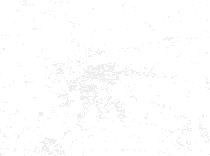
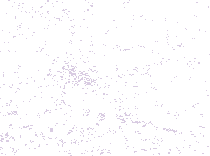
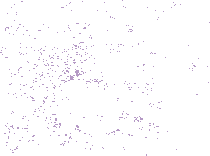
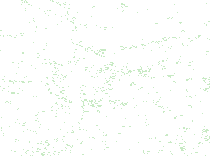
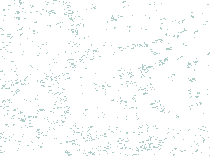
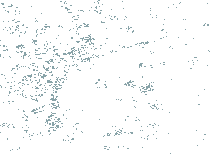
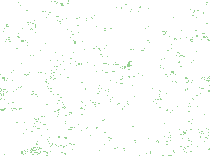
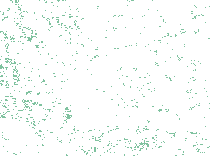
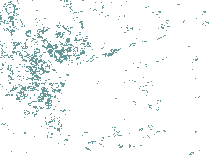

In [245]:
# ── Bivariate classification: vegetation (rows) × income (cols) ───────────────
_N = 3
# Low veg + low income = light grey  |  High veg + high income = dark teal
# Low veg + high income = purple     |  High veg + low income  = green
_BIVAR_PALETTE_3x3 = np.array([
    # income →   low        mid        high
    ["#e8e8e8", "#cbb8d7", "#9972af"],  # veg: low   (grey  → purple)
    ["#b3e2ad", "#8fb8b1", "#5a7f87"],  # veg: mid
    ["#6dbf67", "#4eab7a", "#2a7070"],  # veg: high  (green → dark teal)
])


def _qclass(arr, k):
    flat = arr[np.isfinite(arr)]
    qs   = np.quantile(flat, np.linspace(0, 1, k + 1)); qs[-1] += 1e-9
    out  = np.full(arr.shape, np.nan)
    for i in range(k):
        out[(arr >= qs[i]) & (arr < qs[i + 1])] = i
    return out

_cls_ver     = _qclass(ds_clip["ver"].values.astype(float), _N)
_cls_snv     = _qclass(ds_clip["ind_snv"].values.astype(float), _N)
_bv_combined = np.where(
    np.isfinite(_cls_ver) & np.isfinite(_cls_snv),
    _cls_ver * _N + _cls_snv, np.nan
)

_VEG_LABS = ["Low veg.", "Med. veg.", "High veg."]
_INC_LABS = ["Low income", "Med. income", "High income"]

# ── Single interactive Folium map — 9 toggleable Brewer DivSeq classes ────────
m9 = folium.Map(location=_CENTER, zoom_start=12, tiles=None)
folium.TileLayer("CartoDB positron", name="Basemap").add_to(m9)

for ia in range(_N):
    for ib in range(_N):
        code  = ia * _N + ib
        color = _BIVAR_PALETTE_3x3[ia, ib]
        label = f"{_VEG_LABS[ia]} × {_INC_LABS[ib]}"
        mask  = _bv_combined == code
        if not mask.any():
            continue
        folium.raster_layers.ImageOverlay(
            image=_mask_to_png(mask, color, flip_y=_FLIP_Y),
            bounds=_BOUNDS, name=label, opacity=1.0,
            show=True, zindex=100 + code,
        ).add_to(m9)

folium.LayerControl(collapsed=False).add_to(m9)
m9

---
## Part 5 – Local Spatial Autocorrelation: Hot Spots and Cold Spots

Bivariate maps show *co-location* of two variables, but they do not tell us whether a
high-value cell is surrounded by other high-value cells — i.e., whether spatial **clusters**
exist and are statistically significant.

**Local Moran's I** (Anselin 1995) answers exactly that question for a single variable:

$$I_i = z_i \cdot \bar{z}_{\mathcal{N}(i)}$$

where $z_i$ is the standardised value at cell $i$ and $\bar{z}_{\mathcal{N}(i)}$ is the
mean standardised value in its queen neighbourhood (8 adjacent cells).

| Sign of $I_i$ | $z_i > 0$ | $z_i < 0$ |
|---------------|-----------|-----------|
| $I_i > 0$ (neighbours agree) | **HH** – high–high hotspot | **LL** – low–low coldspot |
| $I_i < 0$ (neighbours differ) | **HL** – spatial outlier | **LH** – spatial outlier |

Significance is assessed via a conditional permutation test (999 random shuffles of the
values at all *other* cells, keeping $z_i$ fixed).

We apply this to **vegetation cover** and **median income** separately, then overlay both
LISA maps to identify zones that are simultaneously vegetation-poor and income-poor (the
most heat-vulnerable areas).

In [258]:
from scipy.ndimage import convolve as ndimage_convolve

# ── Local Moran's I on a 2D raster (queen contiguity) ─────────────────────────
def local_morans_i(arr, n_perms=999, alpha=0.05, seed=42):
    """
    Compute Local Moran's I for each cell of a 2D raster.

    Parameters
    ----------
    arr      : 2D float array (NaN = missing)
    n_perms  : number of permutations for the pseudo p-value
    alpha    : significance level

    Returns
    -------
    li       : Local Moran's I values (same shape as arr)
    cluster  : integer map   1=HH  2=LL  3=HL  4=LH  0=ns  NaN=missing
    p_val    : pseudo p-values
    """
    valid = np.isfinite(arr)
    flat  = arr[valid]
    mu, sigma = flat.mean(), flat.std()
    z     = np.where(valid, (arr - mu) / sigma, np.nan)
    z0    = np.where(valid, z, 0.0)          # NaN → 0 for convolution

    # Queen kernel (8 neighbours)
    W = np.array([[1, 1, 1],
                  [1, 0, 1],
                  [1, 1, 1]], dtype=float)

    n_neigh   = ndimage_convolve(valid.astype(float), W, mode="constant", cval=0)
    lag_sum   = ndimage_convolve(z0, W, mode="constant", cval=0)
    spatial_lag = np.where(n_neigh > 0, lag_sum / n_neigh, np.nan)
    li = np.where(valid, z * spatial_lag, np.nan)

    # ── Conditional permutation test ─────────────────────────────────────────
    # For each permutation, shuffle z values globally and recompute spatial lag.
    # p-value = fraction of |Li_perm| >= |Li|  (two-sided)
    rng     = np.random.default_rng(seed)
    flat_z  = z[valid]
    p_count = np.zeros(arr.shape, dtype=float)

    for _ in range(n_perms):
        z_perm       = np.full(arr.shape, np.nan)
        z_perm[valid] = rng.permutation(flat_z)
        z0_perm       = np.where(valid, z_perm, 0.0)
        lag_perm      = np.where(
            n_neigh > 0,
            ndimage_convolve(z0_perm, W, mode="constant", cval=0) / n_neigh,
            np.nan,
        )
        li_perm = np.where(valid, z * lag_perm, np.nan)
        # accumulate where |li_perm| >= |li|
        with np.errstate(invalid="ignore"):
            p_count += np.where(
                valid & np.isfinite(li_perm),
                (np.abs(li_perm) >= np.abs(li)).astype(float),
                0.0,
            )

    p_val = np.where(valid, p_count / n_perms, np.nan)

    # ── Classify ─────────────────────────────────────────────────────────────
    cluster = np.full(arr.shape, np.nan)
    sig = valid & (p_val <= alpha)

    cluster[sig & (z > 0) & (spatial_lag > 0)] = 1   # HH – hotspot
    cluster[sig & (z < 0) & (spatial_lag < 0)] = 2   # LL – coldspot
    cluster[sig & (z > 0) & (spatial_lag < 0)] = 3   # HL – outlier (high, low nbrs)
    cluster[sig & (z < 0) & (spatial_lag > 0)] = 4   # LH – outlier (low, high nbrs)
    cluster[valid & ~sig]                        = 0  # not significant

    return li, cluster, p_val


# ── Helper: plot a LISA cluster map ──────────────────────────────────────────
_LISA_COLORS = {
    1: "#d7191c",   # HH – red
    2: "#2c7bb6",   # LL – blue
    3: "#fdae61",   # HL – orange
    4: "#abd9e9",   # LH – light blue
    0: "#cccccc",   # ns – grey
}
_LISA_LABELS = {
    1: "HH – hotspot",
    2: "LL – coldspot",
    3: "HL – spatial outlier",
    4: "LH – spatial outlier",
    0: "Not significant",
}


### 5.1 LISA for vegetation cover and median income

We compute Local Moran's I on:
1. **Vegetation cover** (`ver`) – HH clusters = green oases; LL clusters = vegetation deserts
2. **Median income** (`ind_snv`) – HH clusters = wealthy zones; LL clusters = deprived zones

*Note: 999 permutations per variable — this may take ~1–2 minutes.*

In [205]:
# ── Compute LISA for vegetation and income ────────────────────────────────────
arr_ver = ds_clip["ver"].values.astype(float)
arr_snv = ds_clip["ind_snv"].values.astype(float)

print("Computing LISA for vegetation cover...")
li_ver, cluster_ver, p_ver = local_morans_i(arr_ver, n_perms=999)
print("Computing LISA for median income...")
li_snv, cluster_snv, p_snv = local_morans_i(arr_snv, n_perms=999)
print("Done.")

# ── Summary statistics ────────────────────────────────────────────────────────
for name, cluster in [("Vegetation (ver)", cluster_ver), ("Income (ind_snv)", cluster_snv)]:
    total = np.sum(np.isfinite(cluster))
    print(f"\n{name}")
    for code, label in _LISA_LABELS.items():
        n = np.sum(cluster == code)
        print(f"  {label:30s}: {n:6,.0f}  ({100*n/total:.1f} %)")

Computing LISA for vegetation cover...
Computing LISA for median income...
Done.

Vegetation (ver)
  HH – hotspot                  :  1,408  (10.6 %)
  LL – coldspot                 :  1,844  (13.9 %)
  HL – spatial outlier          :    179  (1.3 %)
  LH – spatial outlier          :    127  (1.0 %)
  Not significant               :  9,737  (73.2 %)

Income (ind_snv)
  HH – hotspot                  :  1,989  (15.0 %)
  LL – coldspot                 :  1,914  (14.4 %)
  HL – spatial outlier          :     88  (0.7 %)
  LH – spatial outlier          :    144  (1.1 %)
  Not significant               :  9,160  (68.9 %)



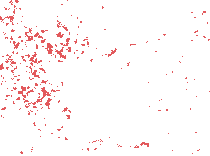
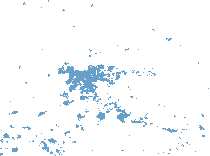
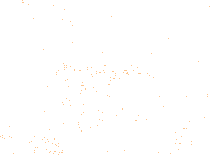
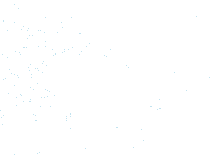
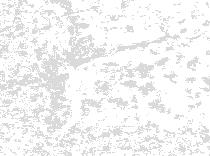
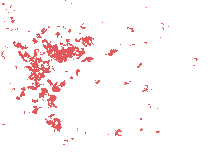
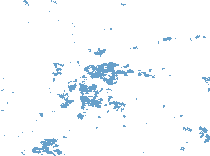
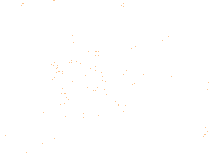
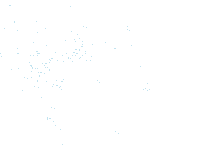
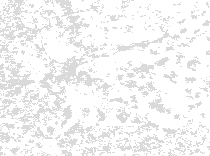

In [259]:
# ── Folium DualMap: left = vegetation LISA, right = income LISA ───────────────
m_lisa = DualMap(location=_CENTER, zoom_start=12)
for tile_m in (m_lisa.m1, m_lisa.m2):
    folium.TileLayer("CartoDB positron", name="Basemap").add_to(tile_m)

for code, color in _LISA_COLORS.items():
    label = _LISA_LABELS[code]

    # Left panel: vegetation LISA
    mask_ver = cluster_ver == code
    if mask_ver.any():
        folium.raster_layers.ImageOverlay(
            image=_mask_to_png(mask_ver, color, flip_y=_FLIP_Y),
            bounds=_BOUNDS, name=label, opacity=1.0,
            show=(code != 0), zindex=100 + code,
        ).add_to(m_lisa.m1)

    # Right panel: income LISA
    mask_snv = cluster_snv == code
    if mask_snv.any():
        folium.raster_layers.ImageOverlay(
            image=_mask_to_png(mask_snv, color, flip_y=_FLIP_Y),
            bounds=_BOUNDS, name=label, opacity=1.0,
            show=(code != 0), zindex=100 + code,
        ).add_to(m_lisa.m2)

folium.LayerControl(collapsed=False).add_to(m_lisa.m1)
folium.LayerControl(collapsed=False).add_to(m_lisa.m2)
m_lisa

### 5.2 Local Lee's L — bivariate spatial autocorrelation

Instead of overlaying two separate LISA maps, we use the **Local Lee's L statistic**
(Lee 2001), which directly measures the *bivariate* spatial co-variation of two variables at
each location:

$$L_i = \frac{1}{2}\!\left(z_{x,i}\,\bar{z}_{y,i} + z_{y,i}\,\bar{z}_{x,i}\right)$$

where $\bar{z}_{y,i}$ is the row-standardised queen-neighbourhood lag of $z_y$.

$L_i > 0$ means the two variables **co-cluster** at location $i$ — both are high together
(HH) or both are low together (LL).  
$L_i < 0$ means a **spatial mismatch** — one variable is high while the other is low in
the neighbourhood (HL or LH).

Applied here with **x = vegetation** and **y = income**:

| Quadrant | Interpretation |
|----------|----------------|
| **LL** (dark red) | Low veg AND low-income neighbourhood → **double-burden hotspot** |
| **HH** (dark blue) | High veg AND high-income neighbourhood → privileged green zone |
| **HL** (orange) | High veg, low-income neighbourhood → green but poor |
| **LH** (light blue) | Low veg, high-income neighbourhood → affluent but built-up |

Significance is assessed by permuting $z_y$ (999 shuffles), keeping $z_x$ fixed.

In [207]:
def local_lee_l(arr_x, arr_y, n_perms=999, alpha=0.05, seed=42):
    """
    Local Lee's L bivariate spatial autocorrelation (Lee 2001).

    L_i = 0.5 * (z_x,i * lag(z_y)_i  +  z_y,i * lag(z_x)_i)

    Quadrant classification (significant cells only):
        1 = HH  z_x > 0, lag(z_y) > 0  → both co-cluster high
        2 = LL  z_x < 0, lag(z_y) < 0  → both co-cluster low  (vulnerability hotspot)
        3 = HL  z_x > 0, lag(z_y) < 0  → spatial mismatch
        4 = LH  z_x < 0, lag(z_y) > 0  → spatial mismatch
        0 = not significant
    """
    valid = np.isfinite(arr_x) & np.isfinite(arr_y)

    def _standardise(arr):
        flat = arr[valid]
        return np.where(valid, (arr - flat.mean()) / flat.std(), np.nan)

    zx = _standardise(arr_x)
    zy = _standardise(arr_y)

    W = np.array([[1, 1, 1],
                  [1, 0, 1],
                  [1, 1, 1]], dtype=float)
    valid_f = valid.astype(float)
    n_neigh = ndimage_convolve(valid_f, W, mode="constant", cval=0)

    def _lag(z):
        z0 = np.where(valid, z, 0.0)
        lag_sum = ndimage_convolve(z0, W, mode="constant", cval=0)
        return np.where(n_neigh > 0, lag_sum / n_neigh, np.nan)

    lag_zx = _lag(zx)
    lag_zy = _lag(zy)

    L = np.where(valid, 0.5 * (zx * lag_zy + zy * lag_zx), np.nan)

    # ── Permutation test: fix z_x, shuffle z_y ───────────────────────────────
    rng    = np.random.default_rng(seed)
    flat_zy = zy[valid]
    p_count = np.zeros(arr_x.shape, dtype=float)

    for _ in range(n_perms):
        zy_perm        = np.full(arr_x.shape, np.nan)
        zy_perm[valid] = rng.permutation(flat_zy)
        lag_zy_perm    = _lag(zy_perm)
        zy_perm0       = np.where(valid, zy_perm, 0.0)
        L_perm = np.where(valid,
                          0.5 * (zx * lag_zy_perm + zy_perm * lag_zx), np.nan)
        with np.errstate(invalid="ignore"):
            p_count += np.where(
                valid & np.isfinite(L_perm),
                (np.abs(L_perm) >= np.abs(L)).astype(float),
                0.0,
            )

    p_val = np.where(valid, p_count / n_perms, np.nan)

    # ── Classify by sign of z_x and lag(z_y) ─────────────────────────────────
    cluster = np.full(arr_x.shape, np.nan)
    sig = valid & (p_val <= alpha)

    cluster[sig & (zx > 0) & (lag_zy > 0)] = 1   # HH
    cluster[sig & (zx < 0) & (lag_zy < 0)] = 2   # LL  ← double burden
    cluster[sig & (zx > 0) & (lag_zy < 0)] = 3   # HL
    cluster[sig & (zx < 0) & (lag_zy > 0)] = 4   # LH
    cluster[valid & ~sig]                   = 0   # not significant

    return L, cluster, p_val, lag_zy


# ── Compute Local Lee's L for vegetation × income ────────────────────────────
print("Computing Local Lee's L (vegetation × income)  — 999 permutations …")
L_vi, cluster_lee, p_lee, lag_zy_vi = local_lee_l(
    arr_ver, arr_snv, n_perms=999
)
print("Done.")

# ── Summary ───────────────────────────────────────────────────────────────────
labels_lee = {1: "HH – both high",
              2: "LL – both low (double burden)",
              3: "HL – high veg, low-income neighbours",
              4: "LH – low veg, high-income neighbours",
              0: "Not significant"}
total_lee = int(np.sum(np.isfinite(cluster_lee)))
print(f"\nLocal Lee's L  (vegetation × income)  —  n = {total_lee:,} cells")
for code, label in labels_lee.items():
    n = int(np.sum(cluster_lee == code))
    print(f"  {label:45s}: {n:6,}  ({100*n/total_lee:.1f} %)")

Computing Local Lee's L (vegetation × income)  — 999 permutations …
Done.

Local Lee's L  (vegetation × income)  —  n = 13,295 cells
  HH – both high                               :  1,340  (10.1 %)
  LL – both low (double burden)                :  1,122  (8.4 %)
  HL – high veg, low-income neighbours         :    174  (1.3 %)
  LH – low veg, high-income neighbours         :    187  (1.4 %)
  Not significant                              : 10,472  (78.8 %)



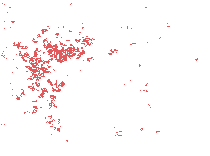
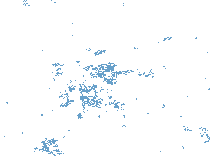
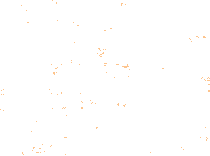
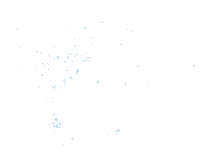
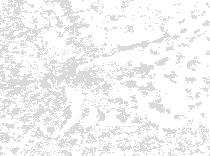

In [261]:
# ── Folium map for Local Lee's L — one toggleable layer per quadrant ─────────
m_lee = folium.Map(location=_CENTER, zoom_start=12, tiles=None)
folium.TileLayer("CartoDB positron", name="Basemap").add_to(m_lee)

_LEE_COLORS = {
    1: "#d7191c",   # HH – red
    2: "#2c7bb6",   # LL – blue
    3: "#fdae61",   # HL – orange
    4: "#abd9e9",   # LH – light blue
    0: "#cccccc",   # ns – grey
}
_LEE_LABELS = {
    1: "HH – both high",
    2: "LL – both low (double burden)",
    3: "HL – high veg, low-income neighbours",
    4: "LH – low veg, high-income neighbours",
    0: "Not significant"
}

for code, color in _LEE_COLORS.items():
    mask = cluster_lee == code
    if not mask.any():
        continue
    folium.raster_layers.ImageOverlay(
        image=_mask_to_png(mask, color, flip_y=_FLIP_Y),
        bounds=_BOUNDS,
        name=_LEE_LABELS[code],
        opacity=1.0,
        show=(code != 0),     # hide "not significant" by default
        zindex=100 + code,
    ).add_to(m_lee)

folium.LayerControl(collapsed=False).add_to(m_lee)
m_lee

---
### 5.3 Local Lee's L — Income × Healthcare access

Beyond vegetation, heat vulnerability is amplified by **limited access to healthcare**:
elderly and poor residents who are far from a hospital or clinic cannot reach care quickly
during a heatwave.

We now compute $L_i$ for:

$$x = \text{ind\_snv} \quad \text{(median income)} \qquad y = \min(\text{dist\_hospital},\, \text{dist\_clinic}) \quad \text{(m)}$$

The quadrant interpretation shifts because distance is a *cost* rather than a benefit:

| Quadrant | $z_x$ (income) | $\bar{z}_y$ (neighbours' distance) | Interpretation |
|----------|-----------|----------------------------------|----------------|
| **LH** (dark red) | low | high | Low income + far from care → **double burden** |
| **HL** (dark blue) | high | low | High income + close to care → most privileged |
| **LL** | low | low | Low income, but healthcare accessible |
| **HH** | high | high | High income, but isolated from care |

Significance: 999-permutation test, $\alpha = 0.05$.

In [209]:
# ── Build min(dist_hospital, dist_clinic) ────────────────────────────────────
arr_dist_hosp   = ds_clip["dist_hospital"].values.astype(float)
arr_dist_clinic = ds_clip["dist_clinic"].values.astype(float)

arr_min_dist = np.where(
    np.isfinite(arr_dist_hosp) & np.isfinite(arr_dist_clinic),
    np.minimum(arr_dist_hosp, arr_dist_clinic),
    np.where(np.isfinite(arr_dist_hosp),   arr_dist_hosp,
    np.where(np.isfinite(arr_dist_clinic), arr_dist_clinic, np.nan))
)

print(f"min(dist_hospital, dist_clinic)  "
      f"— mean: {np.nanmean(arr_min_dist):.0f} m  "
      f"| median: {np.nanmedian(arr_min_dist):.0f} m  "
      f"| max: {np.nanmax(arr_min_dist):.0f} m")

# ── Local Lee's L: income × min healthcare distance ───────────────────────────
print("\nComputing Local Lee's L  (income × min healthcare distance) …")
L_ih, cluster_ih, p_ih, _ = local_lee_l(arr_snv, arr_min_dist, n_perms=999)
print("Done.")

# Custom labels: LH = double burden (low income, far neighbourhood)
_IH_LABELS = {
    1: "HH – high income + far neighbourhood",
    2: "LL – low income + close neighbourhood  (accessible)",
    3: "HL – high income + close neighbourhood (most privileged)",
    4: "LH – low income + far neighbourhood   ← double burden",
    0: "Not significant (p > 0.05)",
}
total_ih = int(np.sum(np.isfinite(cluster_ih)))
print(f"\nIncome × min-healthcare distance  —  n = {total_ih:,} cells")
for code, label in _IH_LABELS.items():
    n = int(np.sum(cluster_ih == code))
    print(f"  {label:55s}: {n:6,}  ({100*n/total_ih:.1f} %)")

min(dist_hospital, dist_clinic)  — mean: 5986 m  | median: 5602 m  | max: 15400 m

Computing Local Lee's L  (income × min healthcare distance) …
Done.

Income × min-healthcare distance  —  n = 13,295 cells
  HH – high income + far neighbourhood                   :    698  (5.3 %)
  LL – low income + close neighbourhood  (accessible)    :  1,144  (8.6 %)
  HL – high income + close neighbourhood (most privileged):    760  (5.7 %)
  LH – low income + far neighbourhood   ← double burden  :  1,182  (8.9 %)
  Not significant (p > 0.05)                             :  9,511  (71.5 %)



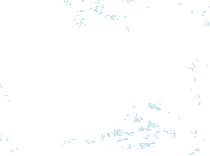
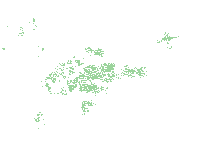
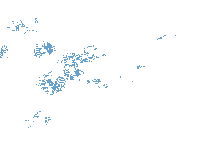
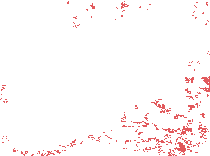
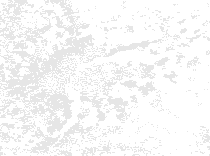

In [210]:
# ── Colour scheme: highlight LH double burden and HL privilege ────────────────
_IH_COLORS = {
    1: "#abd9e9",   # HH – light blue (high income, far)
    2: "#74c476",   # LL – green      (low income, close = accessible)
    3: "#2c7bb6",   # HL – dark blue  (high income, close = most privileged)
    4: "#d7191c",   # LH – red        (low income, far  = double burden)
    0: "#dddddd",   # not significant
}

# ── Folium map ────────────────────────────────────────────────────────────────
m_ih = folium.Map(location=_CENTER, zoom_start=12, tiles=None)
folium.TileLayer("CartoDB positron", name="Basemap").add_to(m_ih)

for code, color in _IH_COLORS.items():
    mask = cluster_ih == code
    if not mask.any():
        continue
    folium.raster_layers.ImageOverlay(
        image=_mask_to_png(mask, color, flip_y=_FLIP_Y),
        bounds=_BOUNDS,
        name=_IH_LABELS[code],
        opacity=1.0,
        show=(code != 0),
        zindex=100 + code,
    ).add_to(m_ih)

folium.LayerControl(collapsed=False).add_to(m_ih)

# Annotation
n_lh = int(np.sum(cluster_ih == 4))
n_hl = int(np.sum(cluster_ih == 3))
folium.map.Marker(
    location=_CENTER,
    icon=folium.DivIcon(
        html=(
            f'<div style="font-family:sans-serif;font-size:11px;'
            f'background:rgba(255,255,255,.85);padding:5px 8px;'
            f'border-radius:4px;border:1px solid #ccc;white-space:nowrap;">'
            f'<b>Double-burden LH</b>: {n_lh:,} cells ({100*n_lh/total_ih:.1f}%)<br>'
            f'<b>Privileged HL</b>: {n_hl:,} cells ({100*n_hl/total_ih:.1f}%)'
            f'</div>'
        ),
        icon_size=(260, 50), icon_anchor=(0, 0)
    )
).add_to(m_ih)

m_ih

> **❓ Question 12.b · Income × Healthcare access — double burden**
>
> 1. Where are the **LH double-burden zones** (dark red) concentrated?
>    Do they overlap with the LL vegetation clusters from section 5.1?
>    *(Activate the LISA income map alongside this one to compare.)*
>
> 2. The **HL clusters** (dark blue) indicate wealthy areas close to healthcare.
>    Are they located in the same neighbourhoods as the HH vegetation clusters?
>
> 3. Compare the share of LH cells here with the share of LL cells in the
>    vegetation × income Lee's L (section 5.2).
>    Which dimension of vulnerability appears more spatially concentrated?
>
> 4. What would a composite vulnerability index look like if it combined:
>    - Low vegetation (section 5.1 LL veg cluster)
>    - Low income (section 5.2 LL income × veg cluster)
>    - Far from healthcare (this map's LH cluster)?
>    Sketch the formula and name the resulting index.

> **❓ Question 12 · Local spatial autocorrelation — LISA and Local Lee's L**
>
> **Part A — Reading the univariate LISA maps (section 5.1)**
>
> 1. Where are the **HH vegetation clusters** (green hotspots)?
>    Are they inside the city or on the periphery?
> 2. Where are the **LL vegetation clusters** (vegetation deserts)?
>    Do they coincide with densely built LCZ classes (1–3)?
> 3. Do the **LL income clusters** and the **LL vegetation clusters** overlap spatially?
>
> **Part B — Local Lee's L map (section 5.2)**
>
> 4. What is the geographic distribution of the **LL double-burden hotspots**
>    (low vegetation co-clustering with low income)?
>    Which parts of the Lyon area are most affected?
> 5. The **HL cells** (high vegetation, low-income neighbourhood) represent a different
>    spatial configuration. What urban or peri-urban form could produce this pattern?
> 6. Compare the Local Lee's L map with the bivariate map from Question 9.
>    - Do both methods identify the same vulnerable zones?
>    - What does Local Lee's L add that the bivariate map alone cannot show?
>    *(Hint: think about statistical significance and spatial contiguity.)*
>
> **Part C — Methodology**
>
> 7. **Lee vs. double-LISA overlay**: why is computing a single $L_i$ statistic on the
>    pair (vegetation, income) more rigorous than overlaying two separate LISA maps?
> 8. The permutation test fixes $z_x$ (vegetation) and shuffles $z_y$ (income).
>    What null hypothesis does this test?
>    Would the result change if we also shuffled $z_x$?
> 9. What are the limits of this raster-based approach compared to working with
>    administrative polygons (IRIS, quartier)?
>    When would one scale be preferred over the other?

---
## Conclusion

In this notebook we have shown that Lyon, like most French cities, is experiencing:

1. **Accelerating warming** – roughly +3 °C over 55 years, with more frequent and longer heatwaves.
2. **Unequal exposure** – lower-income urban areas have less vegetation, more impervious surfaces, and greater distances to healthcare.
3. **Climate justice concerns** – the populations least responsible for climate change bear a disproportionate share of its health consequences.

### Further reading


- Lemonsu et al. (2015). *Vulnerability to heat waves: Future heat exposure and human comfort for the agglomeration of Marseille.* Urban Climate.
- Stewart & Oke (2012). *Local Climate Zones for Urban Ecosystem Studies.* BAMS.
- Tuholske et al. (2021). *Global urban population exposure to extreme heat.* PNAS.
